In [ ]:
import pandas as pd
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uom190346a/water-quality-and-potability")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'water-quality-and-potability' dataset.
Path to dataset files: /kaggle/input/water-quality-and-potability


In [ ]:
import pandas as pd
# The path to the dataset files was printed after downloading from KaggleHub
# Make sure to use the correct path to the CSV file
df = pd.read_csv('/kaggle/input/water-quality-and-potability/water_potability.csv')

In [ ]:
import pandas as pd
import numpy as np

# Display the first few rows to get an overview
print(df.head())

         ph    Hardness        Solids  Chloramines     Sulfate  Conductivity  \
0       NaN  204.890455  20791.318981     7.300212  368.516441    564.308654   
1  3.716080  129.422921  18630.057858     6.635246         NaN    592.885359   
2  8.099124  224.236259  19909.541732     9.275884         NaN    418.606213   
3  8.316766  214.373394  22018.417441     8.059332  356.886136    363.266516   
4  9.092223  181.101509  17978.986339     6.546600  310.135738    398.410813   

   Organic_carbon  Trihalomethanes  Turbidity  Potability  
0       10.379783        86.990970   2.963135           0  
1       15.180013        56.329076   4.500656           0  
2       16.868637        66.420093   3.055934           0  
3       18.436524       100.341674   4.628771           0  
4       11.558279        31.997993   4.075075           0  


#
Analyzing the water potability dataset to identify patterns and build a predictive model.


## Check for missing values




In [ ]:
# Identify missing values
missing_values = df.isnull()
# Count missing values per column
missing_counts = missing_values.sum()
# Print the missing counts
print("Missing values per column:")
print(missing_counts)

Missing values per column:
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


## Visualize feature distributions


visualizations to understand the distribution of each feature.


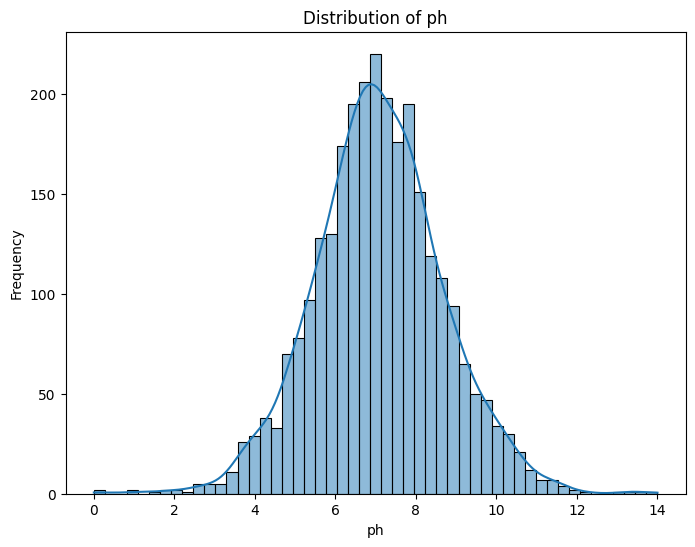

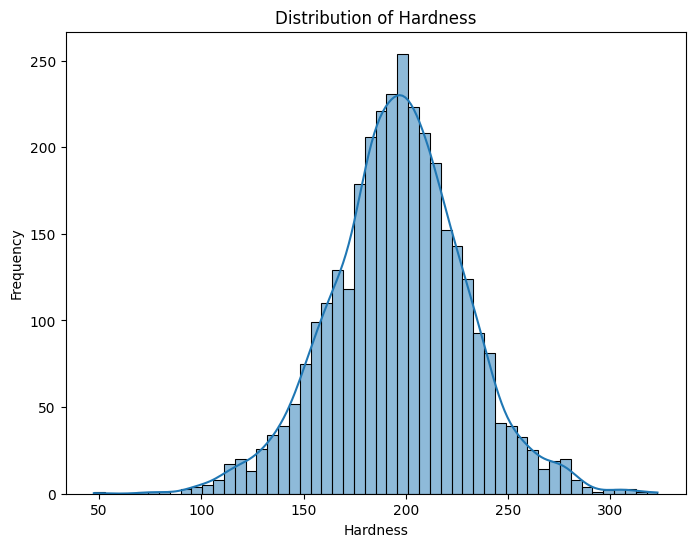

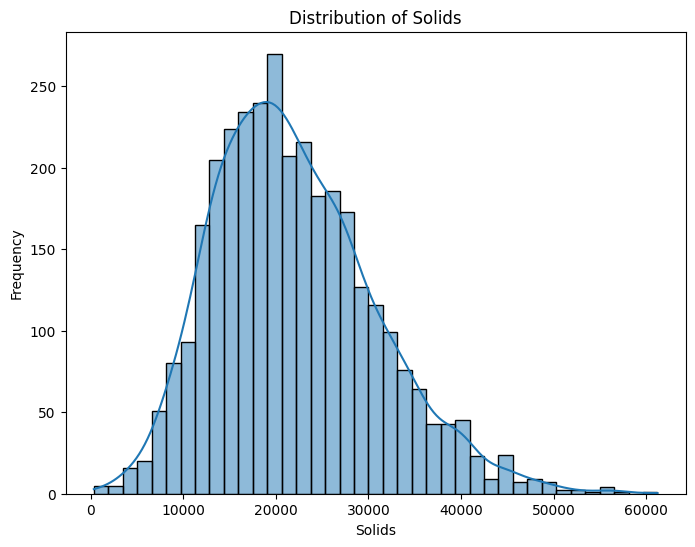

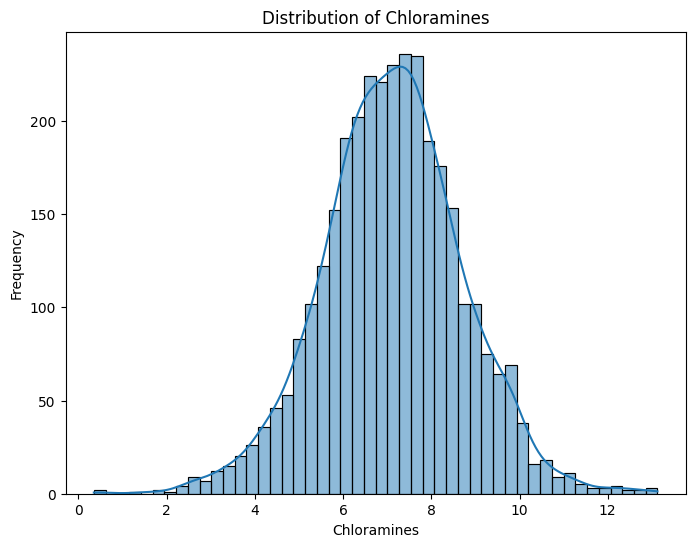

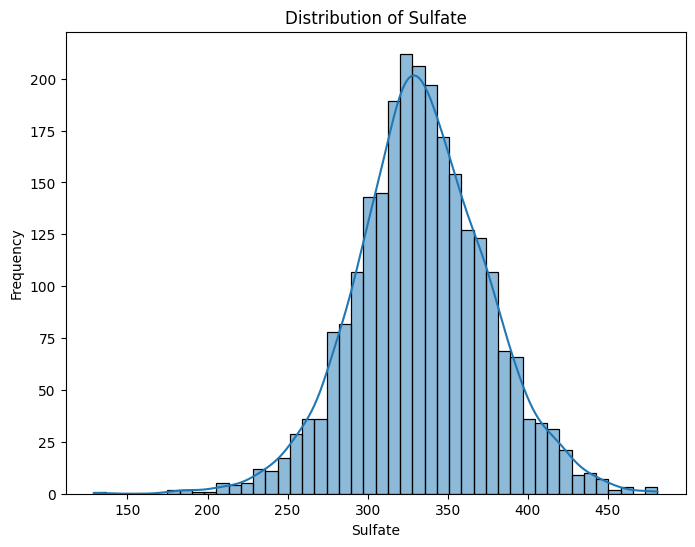

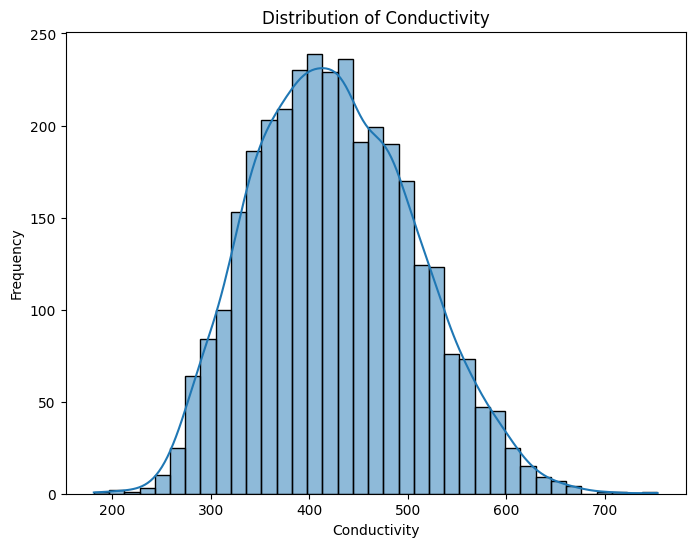

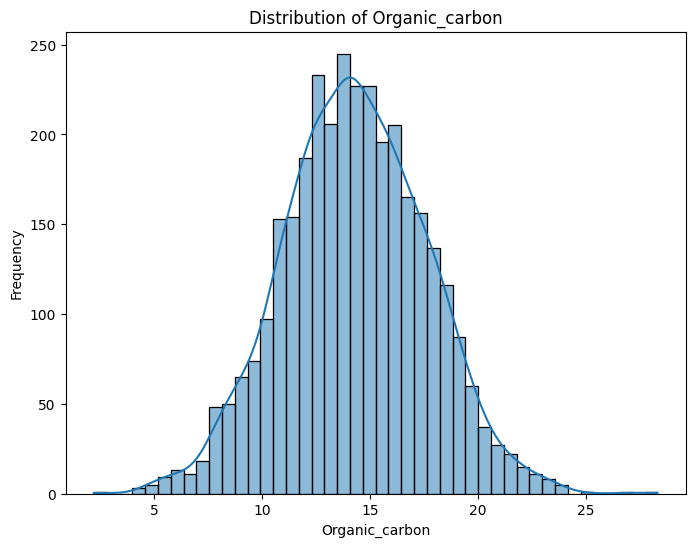

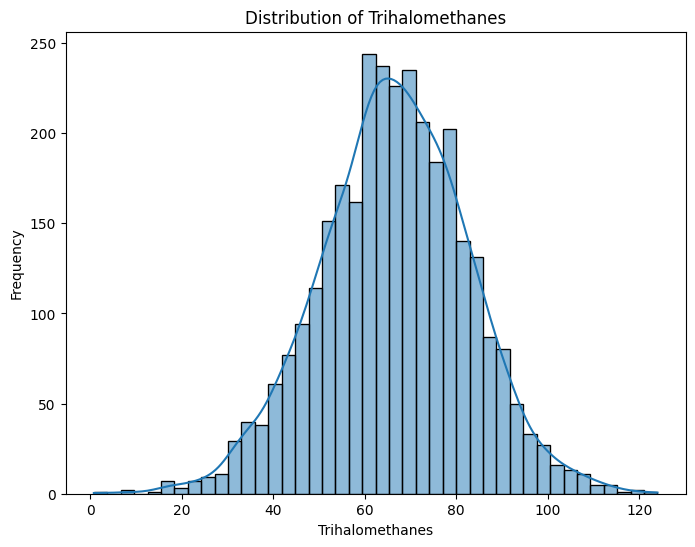

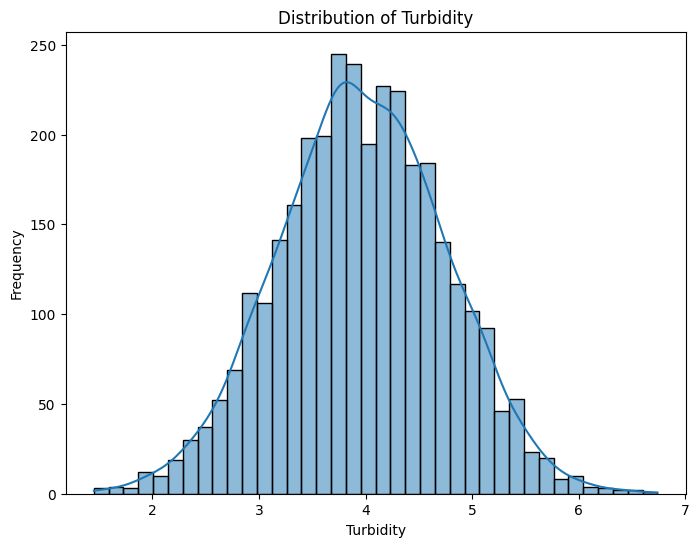

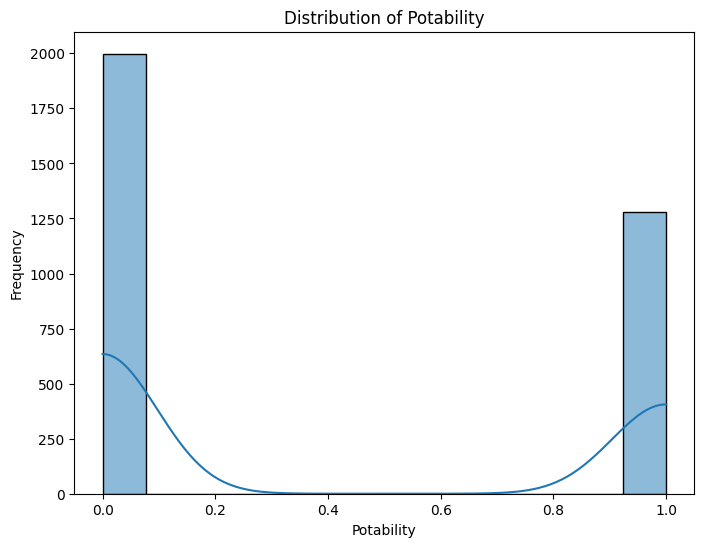

In [ ]:
for column in df.columns:
    plt.figure(figsize=(8, 6))
    sns.histplot(df[column].dropna(), kde=True)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

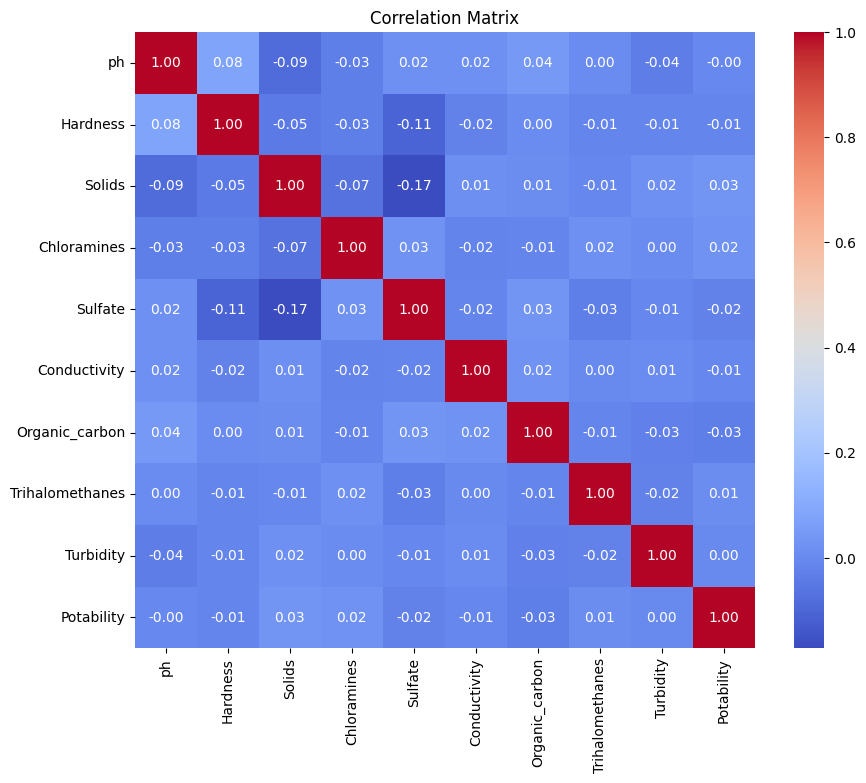

In [ ]:
correlation_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [ ]:
print("Missing values per column after previous steps:")
print(df.isnull().sum())

Missing values per column after previous steps:
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


In [ ]:
df['ph'].fillna(df['ph'].median(), inplace=True)
df['Sulfate'].fillna(df['Sulfate'].median(), inplace=True)
df['Trihalomethanes'].fillna(df['Trihalomethanes'].median(), inplace=True)

print("Missing values per column after imputation:")
print(df.isnull().sum())

Missing values per column after imputation:
ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


/tmp/ipython-input-3806424425.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ph'].fillna(df['ph'].median(), inplace=True)
/tmp/ipython-input-3806424425.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

## Handle class imbalance




In [ ]:
# Separate features (X) and target (y)
X = df.drop('Potability', axis=1)
y = df['Potability']

# Check the distribution of the original target variable
print("Original target variable distribution:")
print(y.value_counts())

# Apply SMOTE to balance the classes
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Check the distribution of the resampled target variable
print("\nResampled target variable distribution:")
print(y_resampled.value_counts())

Original target variable distribution:
Potability
0    1998
1    1278
Name: count, dtype: int64

Resampled target variable distribution:
Potability
0    1998
1    1998
Name: count, dtype: int64


## Prepare data for modeling

necessary data transformations, such as scaling or encoding, before building a predictive model.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Build and evaluate model

evaluating the specified classification models.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'SVM': SVC(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    results[name] = {'accuracy': accuracy, 'report': report}

    print(f"--- {name} Results ---")
    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report:")
    print(report)
    print("-" * (len(name) + 13))

--- Logistic Regression Results ---
Accuracy: 0.5225
Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.57      0.54       394
           1       0.53      0.48      0.50       406

    accuracy                           0.52       800
   macro avg       0.52      0.52      0.52       800
weighted avg       0.52      0.52      0.52       800

--------------------------------
--- SVM Results ---
Accuracy: 0.6837
Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.67      0.68       394
           1       0.68      0.70      0.69       406

    accuracy                           0.68       800
   macro avg       0.68      0.68      0.68       800
weighted avg       0.68      0.68      0.68       800

----------------
--- K-Nearest Neighbors Results ---
Accuracy: 0.6525
Classification Report:
              precision    recall  f1-score   support

           0       0.65      

/tmp/ipython-input-4149047978.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=accuracies, palette='viridis')


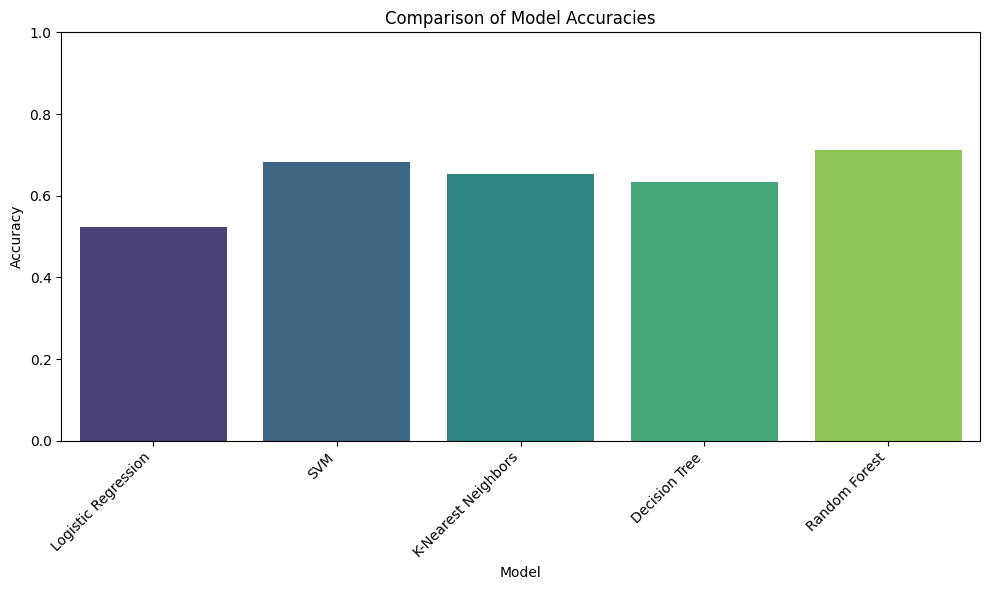

In [ ]:
# Create a bar chart to compare model accuracies
model_names = list(results.keys())
accuracies = [result['accuracy'] for result in results.values()]

plt.figure(figsize=(10, 6))
sns.barplot(x=model_names, y=accuracies, palette='viridis')
plt.title('Comparison of Model Accuracies')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1) # Set y-axis limit from 0 to 1 for accuracy
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

## Feature Importance Analysis


Analyze the feature importance of the best-performing model (Random Forest).

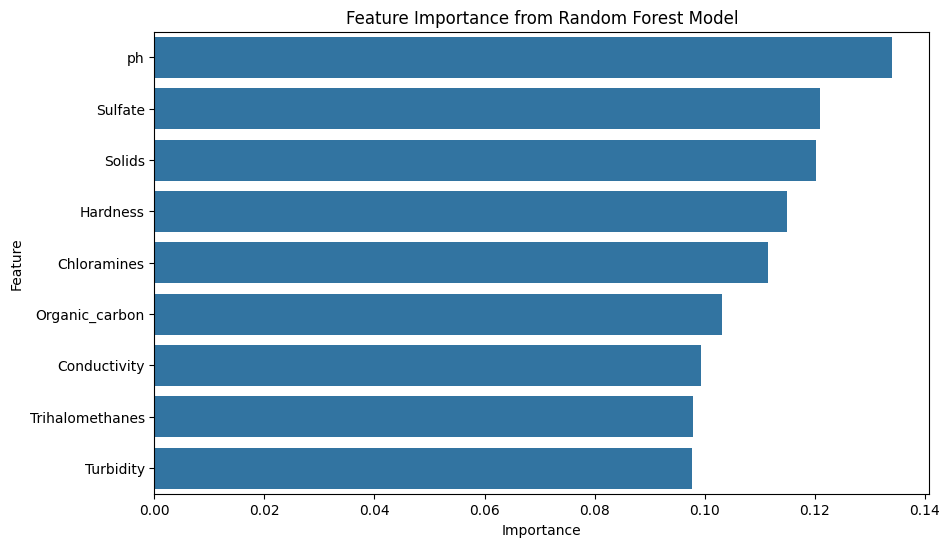

In [ ]:
# Find the best performing model name based on accuracy
best_model_name = max(results, key=lambda k: results[k]['accuracy'])
# Get the best performing model (Random Forest)
best_model = models[best_model_name]

# Get feature importances
feature_importances = best_model.feature_importances_

# Create a pandas Series for easier visualization
feature_importance_series = pd.Series(feature_importances, index=X_resampled.columns)

# Sort the features by importance
sorted_feature_importances = feature_importance_series.sort_values(ascending=False)

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x=sorted_feature_importances.values, y=sorted_feature_importances.index)
plt.title('Feature Importance from Random Forest Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

## Create a Predictive Agent

takes new water quality data as input and predicts potability using the trained Random Forest model.

a function that takes a new data point (or multiple data points) as input, preprocesses it using the same scaler used during training, and then uses the trained Random Forest model to make a prediction.

In [ ]:
def predict_potability(new_data):
    """
    Predicts water potability using the trained Random Forest model.

    Args:
        new_data (dict or list of dicts): A dictionary or list of dictionaries
                                          containing the water quality parameters
                                          for a new data point(s). The keys should
                                          match the feature names used for training.

    Returns:
        numpy.ndarray: An array of predicted potability labels (0 for not potable, 1 for potable).
    """
    # Convert the input data to a pandas DataFrame
    if isinstance(new_data, dict):
        new_df = pd.DataFrame([new_data])
    elif isinstance(new_data, list):
        new_df = pd.DataFrame(new_data)
    else:
        raise ValueError("Input data must be a dictionary or a list of dictionaries.")

    # Ensure the columns are in the same order as the training data
    new_df = new_df[X_resampled.columns]

    # Scale the new data using the same scaler fitted on the training data
    new_data_scaled = scaler.transform(new_df)

    # Make predictions using the best performing model (Random Forest)
    predictions = best_model.predict(new_data_scaled)

    return predictions

## Example Usage of Predictive Agent

how to use the `predict_potability` function with sample data.

a sample data point (dictionary) with water quality parameters and use the `predict_potability` function to get a prediction.

In [ ]:
# Example usage with a single data point
sample_data = {
    'ph': 7.5,
    'Hardness': 180.0,
    'Solids': 20000.0,
    'Chloramines': 6.0,
    'Sulfate': 300.0,
    'Conductivity': 400.0,
    'Organic_carbon': 12.0,
    'Trihalomethanes': 70.0,
    'Turbidity': 4.0
}

prediction = predict_potability(sample_data)

print(f"Sample Data: {sample_data}")
print(f"Predicted Potability: {prediction[0]}")

# Interpret the prediction
if prediction[0] == 1:
    print("The predicted potability for this water sample is: Potable")
else:
    print("The predicted potability for this water sample is: Not Potable")

Sample Data: {'ph': 7.5, 'Hardness': 180.0, 'Solids': 20000.0, 'Chloramines': 6.0, 'Sulfate': 300.0, 'Conductivity': 400.0, 'Organic_carbon': 12.0, 'Trihalomethanes': 70.0, 'Turbidity': 4.0}
Predicted Potability: 1
The predicted potability for this water sample is: Potable
